In [16]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [17]:
df = pd.read_csv("151.1-height_weight.csv")
df.head()

,Height,Weight
0,188,84.2
1,178,76.5
2,164,55.1
3,157,47.4
4,170,76.5


Text(0, 0.5, 'Height')

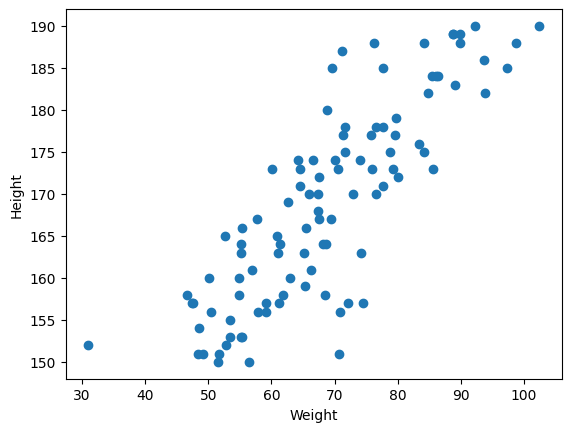

In [19]:
## Scatter Plot
plt.scatter(df["Weight"],df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")

In [20]:
## Correlation
df.corr()

,Height,Weight
Height,1.000000,0.834584
Weight,0.834584,1.000000


In [29]:
! py -3.14 -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


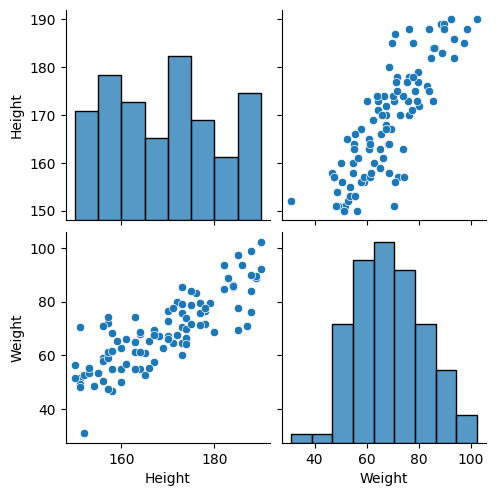

In [30]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [31]:
## Independent and Dependent Features
df.head()

,Height,Weight
0,188,84.2
1,178,76.5
2,164,55.1
3,157,47.4
4,170,76.5


In [34]:
X = df["Weight"]
type(X)
X

0     84.2
1     76.5
2     55.1
3     47.4
4     76.5
      ... 
95    71.3
96    70.9
97    61.8
98    47.5
99    66.3
Name: Weight, Length: 100, dtype: float64

In [39]:
X = df[["Weight"]]
X
np.array(X).shape

(100, 1)

In [40]:
X = df["Weight"]
np.array(X).shape

(100,)

In [42]:
X = df[["Weight"]]
y = df[["Height"]]
np.array(y).shape

(100, 1)

In [52]:
! py -3.14 -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 415.3 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.3 MB 415.3 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.3 MB 415.3 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.3 MB 415.3 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/8.3 MB 371.8 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.3 MB 371.8 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/8.3 MB 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)
X_train.shape

(75, 1)

In [60]:
## Standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test

array([[-1.21941608],
       [ 0.16792622],
       [-1.13993292],
       [-0.66303401],
       [ 0.52921328],
       [-0.52574493],
       [ 1.83707243],
       [-0.76419438],
       [ 0.54366476],
       [ 1.14340128],
       [ 0.81824293],
       [-1.12548144],
       [ 0.75321126],
       [-0.07052323],
       [ 1.27346462],
       [ 0.58701921],
       [ 0.24018364],
       [-0.5040677 ],
       [ 1.46855963],
       [ 1.82984669],
       [-0.93761217],
       [-0.51851919],
       [ 1.07836961],
       [-1.45063979],
       [-0.17168361]])

In [64]:
## Apply Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)
regression.coef_
print("Coefficient or slope :",regression.coef_)
print("Intercept :",regression.intercept_)

Coefficient or slope : [[9.38035697]]
Intercept : [169.05333333]


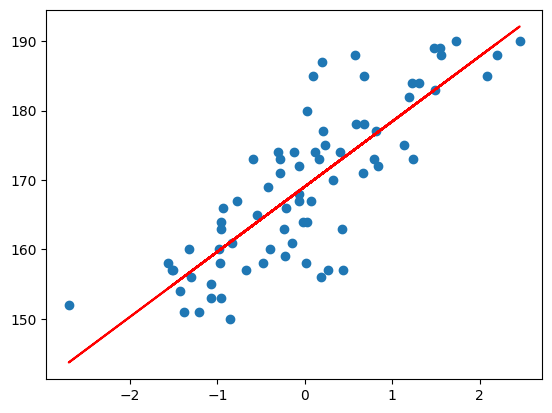

In [66]:
## Ploting training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color = "r")

In [68]:
## Prediction for test data
y_pred = regression.predict(X_test)

In [70]:
## Performance Matrices
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error :",mse)
print("Mean Absolute Error :",mae)
print("Root Mean Squared Error :",rmse)

Mean Squared Error : 38.834693933783065
Mean Absolute Error : 4.8579144800791525
Root Mean Squared Error : 6.231748866392408


In [ ]:
## R Square
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print("R2 Score :",score)

R2 Score : 0.7511872505523893


In [ ]:
## Adjusted R^2
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7403693049242324

In [77]:
! py -3.14 -m pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 559.3 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.6 MB 534.7 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.6 MB 534.7 kB/s eta 0:00:16
   ----- ---------------------------------- 1.3/9.6 MB 524.3 kB/s eta 0:00:16
   ------ --------------------------------- 1.6/9.6 MB 538.5 kB/s eta 0:00:15
   ------ --------------------------------- 1.6/9.6 MB 538.5 kB/s eta 0:00:15
   ------- -------------------------------- 1.8/9.6 MB 540.2 kB/s eta 0:00:15
   -------- ------------------------------- 2.1/9.6 MB 532.6 kB/s eta 0:00:15
   --------- ------------------------------ 2.4/9.6 MB 534.0 kB/s eta 0:00:14
   --------- ------------------------------ 2.4/9.6 MB 534.0 kB/s eta 0:00:14
   ---------- ----------------------------- 2.6/9.6 MB 526.2 kB/s eta 0:00:14
   -


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
## OLS Linear Regression 
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()
prediction = model.predict(X_test)
print(prediction)
print(model.summery())

[-11.4385581    1.57520793 -10.69297775  -6.21949568   4.9642095
  -4.93167508  17.23239518  -7.16841612   5.09976956  10.72551217
   7.67541075 -10.55741769   7.06539047  -0.66153311  11.94555273
   5.50644975   2.25300824  -4.72833499  13.77561358  17.16461515
  -8.79513687  -4.86389505  10.11549188 -13.6075191   -1.61045355]


In [ ]:
## Prediction for newdata
regression.predict([[72]])
regression.predict(scaler.transform([[72]]))